**Lectura del json  exportación a data frame**

In [2]:
#============================================
# Librerías
# ============================================
import pandas as pd

# ============================================
# Leer JSON directamente desde la URL
# ============================================
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

print("Dimensión inicial del dataset:", df.shape)
print("\nColumnas originales:")
print(df.columns)

# ============================================
# Normalizar columnas anidadas
# ============================================

# Normalizar cada columna tipo diccionario
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

# Renombrar columnas para evitar duplicados
customer_df.columns = ["customer_" + col for col in customer_df.columns]
phone_df.columns = ["phone_" + col for col in phone_df.columns]
internet_df.columns = ["internet_" + col for col in internet_df.columns]
account_df.columns = ["account_" + col for col in account_df.columns]

# ============================================
# Unir todo en un solo DataFrame plano
# ============================================

df_final = pd.concat(
    [
        df.drop(columns=['customer', 'phone', 'internet', 'account']),
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)

# ============================================
# Resultado final
# ============================================

print("\nDimensión del dataset normalizado:", df_final.shape)

print("\nPrimeras filas:")
print(df_final.head())

print("\nColumnas finales:")
print(df_final.columns)




Dimensión inicial del dataset: (7267, 6)

Columnas originales:
Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

Dimensión del dataset normalizado: (7267, 21)

Primeras filas:
   customerID Churn customer_gender  customer_SeniorCitizen customer_Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer_Dependents  customer_tenure phone_PhoneService phone_MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes 

**Conocer el conjunto de datos**

In [3]:
# ============================================
# COMPROBACIÓN DE INCOHERENCIAS EN LOS DATOS
# ============================================

import pandas as pd

print("====================================")
print("1. VALORES FALTANTES")
print("====================================")

missing_values = df_final.isnull().sum()
missing_percentage = (df_final.isnull().sum() / len(df_final)) * 100

missing_df = pd.DataFrame({
    "Valores faltantes": missing_values,
    "Porcentaje (%)": missing_percentage
})

print(missing_df[missing_df["Valores faltantes"] > 0])


print("\n====================================")
print("2. REGISTROS DUPLICADOS")
print("====================================")

duplicados = df_final.duplicated().sum()
print(f"Cantidad de registros duplicados: {duplicados}")


print("\n====================================")
print("3. TIPOS DE DATOS")
print("====================================")

print(df_final.dtypes)


print("\n====================================")
print("4. INCONSISTENCIAS EN VARIABLES CATEGÓRICAS")
print("====================================")

# Seleccionar columnas categóricas
categorical_columns = df_final.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"\nColumna: {col}")
    print(df_final[col].value_counts(dropna=False))


print("\n====================================")
print("5. POSIBLES ERRORES EN VARIABLES NUMÉRICAS")
print("====================================")

# Intentar convertir cargos totales a número si viene como texto
if 'account_Charges_Total' in df_final.columns:
    df_final['account_Charges_Total'] = pd.to_numeric(df_final['account_Charges_Total'], errors='coerce')

numeric_columns = df_final.select_dtypes(include=['int64', 'float64']).columns

print(df_final[numeric_columns].describe())


print("\n====================================")
print("6. DETECTAR VALORES VACÍOS COMO TEXTO")
print("====================================")

empty_strings = (df_final == "").sum()

print(empty_strings[empty_strings > 0])

1. VALORES FALTANTES
Empty DataFrame
Columns: [Valores faltantes, Porcentaje (%)]
Index: []

2. REGISTROS DUPLICADOS
Cantidad de registros duplicados: 0

3. TIPOS DE DATOS
customerID                    object
Churn                         object
customer_gender               object
customer_SeniorCitizen         int64
customer_Partner              object
customer_Dependents           object
customer_tenure                int64
phone_PhoneService            object
phone_MultipleLines           object
internet_InternetService      object
internet_OnlineSecurity       object
internet_OnlineBackup         object
internet_DeviceProtection     object
internet_TechSupport          object
internet_StreamingTV          object
internet_StreamingMovies      object
account_Contract              object
account_PaperlessBilling      object
account_PaymentMethod         object
account_Charges.Monthly      float64
account_Charges.Total         object
dtype: object

4. INCONSISTENCIAS EN VARIABLES CATE

In [4]:
# ============================================
# LIMPIEZA Y MANEJO DE INCONSISTENCIAS
# ============================================

import pandas as pd
import numpy as np

print("====================================")
print("1. ELIMINAR DUPLICADOS")
print("====================================")

df_final = df_final.drop_duplicates()
print("Registros después de eliminar duplicados:", df_final.shape)


print("\n====================================")
print("2. CORREGIR VARIABLES NUMÉRICAS")
print("====================================")

# Convertir cargos totales a numérico
df_final['account_Charges.Total'] = pd.to_numeric(
    df_final['account_Charges.Total'], errors='coerce'
)

# Convertir cargos mensuales a numérico (por seguridad)
df_final['account_Charges.Monthly'] = pd.to_numeric(
    df_final['account_Charges.Monthly'], errors='coerce'
)


print("\n====================================")
print("3. MANEJO DE VALORES FALTANTES")
print("====================================")

# En este dataset normalmente TotalCharges es NaN cuando tenure = 0
if 'customer_tenure' in df_final.columns:

    condition = (df_final['customer_tenure'] == 0) & (df_final['account_Charges.Total'].isna())

    df_final.loc[condition, 'account_Charges.Total'] = 0

# Si aún quedan valores faltantes numéricos
numeric_cols = df_final.select_dtypes(include=['int64','float64']).columns
df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].median())


print("\n====================================")
print("4. LIMPIAR VARIABLES CATEGÓRICAS")
print("====================================")

categorical_cols = df_final.select_dtypes(include='object').columns

for col in categorical_cols:

    # eliminar espacios
    df_final[col] = df_final[col].str.strip()

    # estandarizar formato
    df_final[col] = df_final[col].str.capitalize()


print("\n====================================")
print("5. CONVERTIR VARIABLES BINARIAS")
print("====================================")

binary_map = {
    "Yes": 1,
    "No": 0
}

for col in categorical_cols:
    unique_values = df_final[col].dropna().unique()

    if set(unique_values).issubset({"Yes","No"}):
        df_final[col] = df_final[col].map(binary_map)


print("\n====================================")
print("6. VERIFICACIÓN FINAL")
print("====================================")

print("Valores faltantes restantes:")
print(df_final.isnull().sum())

print("\nDimensión final del dataset:")
print(df_final.shape)

print("\nTipos de datos finales:")
print(df_final.dtypes)

print("\nPrimeras filas del dataset limpio:")
print(df_final.head())

1. ELIMINAR DUPLICADOS
Registros después de eliminar duplicados: (7267, 21)

2. CORREGIR VARIABLES NUMÉRICAS

3. MANEJO DE VALORES FALTANTES

4. LIMPIAR VARIABLES CATEGÓRICAS

5. CONVERTIR VARIABLES BINARIAS

6. VERIFICACIÓN FINAL
Valores faltantes restantes:
customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges.Monthly      0
account_Charges.Total        0
dtype: int64

Dimensión final del dataset:
(7267, 21)

Tipos de datos finales:
customerID

In [5]:
# ============================================
# CREAR COLUMNA CUENTAS_DIARIAS
# ============================================

# Verificar que la columna mensual exista
if 'account_Charges.Monthly' in df_final.columns:

    # Calcular facturación diaria
    df_final['Cuentas_Diarias'] = df_final['account_Charges.Monthly'] / 30

    # Redondear a 2 decimales (opcional)
    df_final['Cuentas_Diarias'] = df_final['Cuentas_Diarias'].round(2)

print("Columna 'Cuentas_Diarias' creada correctamente.")

# Verificar resultado
print(df_final[['account_Charges.Monthly', 'Cuentas_Diarias']].head())

Columna 'Cuentas_Diarias' creada correctamente.
   account_Charges.Monthly  Cuentas_Diarias
0                     65.6             2.19
1                     59.9             2.00
2                     73.9             2.46
3                     98.0             3.27
4                     83.9             2.80


In [6]:
# ============================================
# ESTANDARIZACIÓN Y TRANSFORMACIÓN DE DATOS
# ============================================

import pandas as pd

print("====================================")
print("1. CONVERTIR VARIABLES BINARIAS")
print("====================================")

# Diccionario de conversión
binary_map = {
    "Yes": 1,
    "No": 0
}

# Identificar columnas categóricas
categorical_cols = df_final.select_dtypes(include='object').columns

for col in categorical_cols:

    unique_values = df_final[col].dropna().unique()

    # Si solo contiene Yes/No se convierte a binario
    if set(unique_values).issubset({"Yes","No"}):
        df_final[col] = df_final[col].map(binary_map)

print("Conversión de variables binarias completada.")


print("\n====================================")
print("2. TRANSFORMAR VARIABLE CHURN")
print("====================================")

# Convertir churn a binario si existe
if 'Churn' in df_final.columns:
    df_final['Churn'] = df_final['Churn'].map(binary_map)

print("Variable Churn transformada.")


print("\n====================================")
print("3. TRANSFORMAR VARIABLES CATEGÓRICAS")
print("====================================")

# Crear variables dummy para categorías con múltiples valores
df_final = pd.get_dummies(df_final, drop_first=True)

print("Variables categóricas transformadas con one-hot encoding.")


print("\n====================================")
print("4. VERIFICACIÓN FINAL")
print("====================================")

print("Dimensión final del dataset:")
print(df_final.shape)

print("\nTipos de datos:")
print(df_final.dtypes)

print("\nPrimeras filas del dataset transformado:")
print(df_final.head())

1. CONVERTIR VARIABLES BINARIAS
Conversión de variables binarias completada.

2. TRANSFORMAR VARIABLE CHURN
Variable Churn transformada.

3. TRANSFORMAR VARIABLES CATEGÓRICAS
Variables categóricas transformadas con one-hot encoding.

4. VERIFICACIÓN FINAL
Dimensión final del dataset:
(7267, 7298)

Tipos de datos:
Churn                                            float64
customer_SeniorCitizen                             int64
customer_Partner                                   int64
customer_Dependents                                int64
customer_tenure                                    int64
                                                  ...   
account_Contract_One year                           bool
account_Contract_Two year                           bool
account_PaymentMethod_Credit card (automatic)       bool
account_PaymentMethod_Electronic check              bool
account_PaymentMethod_Mailed check                  bool
Length: 7298, dtype: object

Primeras filas del dataset tr

In [7]:
# ============================================
# ANÁLISIS DESCRIPTIVO DEL DATASET
# ============================================

import pandas as pd

print("====================================")
print("1. ESTADÍSTICAS DESCRIPTIVAS GENERALES")
print("====================================")

# Estadísticas básicas para variables numéricas
print(df_final.describe())


print("\n====================================")
print("2. MEDIA, MEDIANA Y DESVIACIÓN ESTÁNDAR")
print("====================================")

mean_values = df_final.mean(numeric_only=True)
median_values = df_final.median(numeric_only=True)
std_values = df_final.std(numeric_only=True)

summary_stats = pd.DataFrame({
    "Media": mean_values,
    "Mediana": median_values,
    "Desviación Estándar": std_values
})

print(summary_stats)


print("\n====================================")
print("3. DISTRIBUCIÓN DE VARIABLES CLAVE")
print("====================================")

key_columns = [
    'customer_tenure',
    'account_Charges_Monthly',
    'account_Charges_Total',
    'Cuentas_Diarias'
]

for col in key_columns:
    if col in df_final.columns:
        print(f"\nResumen estadístico de {col}")
        print(df_final[col].describe())


print("\n====================================")
print("4. DISTRIBUCIÓN DE CHURN")
print("====================================")

if 'Churn' in df_final.columns:

    churn_counts = df_final['Churn'].value_counts()
    churn_percentage = df_final['Churn'].value_counts(normalize=True) * 100

    churn_summary = pd.DataFrame({
        "Cantidad": churn_counts,
        "Porcentaje (%)": churn_percentage
    })

    print(churn_summary)



1. ESTADÍSTICAS DESCRIPTIVAS GENERALES
             Churn  customer_SeniorCitizen  customer_Partner  \
count  7043.000000             7267.000000       7267.000000   
mean      0.265370                0.162653          0.484106   
std       0.441561                0.369074          0.499782   
min       0.000000                0.000000          0.000000   
25%       0.000000                0.000000          0.000000   
50%       0.000000                0.000000          0.000000   
75%       1.000000                0.000000          1.000000   
max       1.000000                1.000000          1.000000   

       customer_Dependents  customer_tenure  phone_PhoneService  \
count          7267.000000      7267.000000         7267.000000   
mean              0.300124        32.346498            0.902711   
std               0.458343        24.571773            0.296371   
min               0.000000         0.000000            0.000000   
25%               0.000000         9.000000      

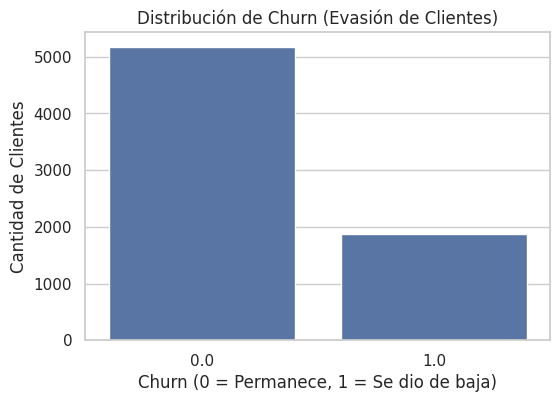

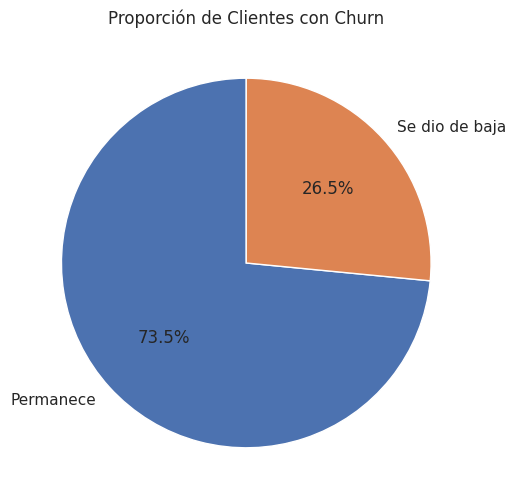

In [8]:
# ============================================
# DISTRIBUCIÓN DE CHURN
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")

# Conteo de churn
churn_counts = df_final['Churn'].value_counts()

# ============================================
# 1. GRÁFICO DE BARRAS
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df_final)

plt.title("Distribución de Churn (Evasión de Clientes)")
plt.xlabel("Churn (0 = Permanece, 1 = Se dio de baja)")
plt.ylabel("Cantidad de Clientes")

plt.show()


# ============================================
# 2. GRÁFICO DE PASTEL
# ============================================

labels = ['Permanece', 'Se dio de baja']

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Proporción de Clientes con Churn")
plt.show()

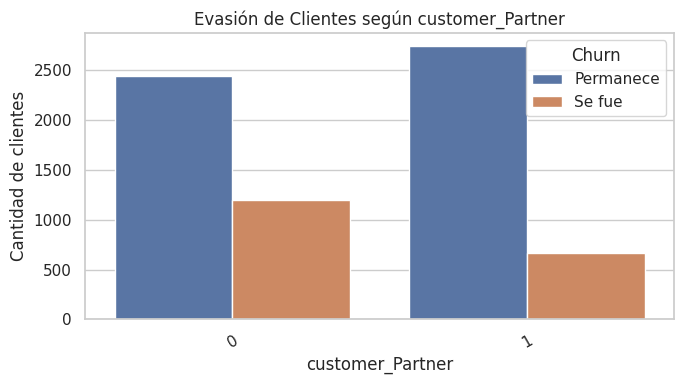

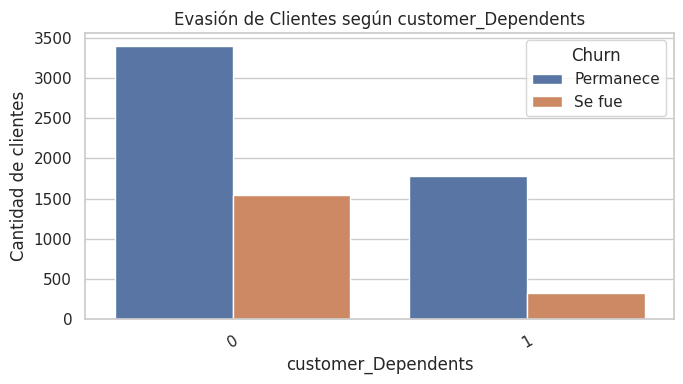

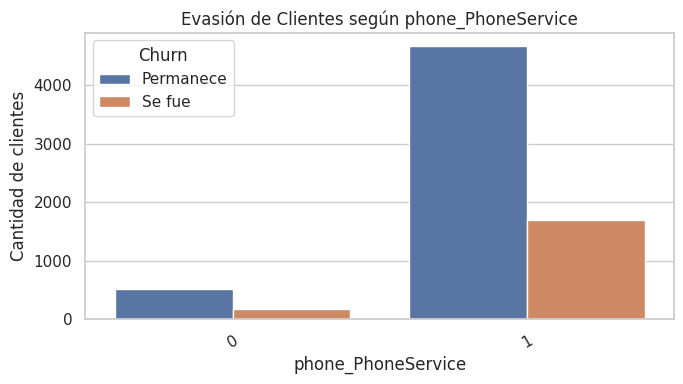

In [9]:
# ============================================
# EVASIÓN POR VARIABLES CATEGÓRICAS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Variables categóricas relevantes
categorical_vars = [
    'customer_gender',
    'customer_Partner',
    'customer_Dependents',
    'phone_PhoneService',
    'internet_InternetService',
    'account_Contract',
    'account_PaymentMethod'
]

for var in categorical_vars:

    if var in df_final.columns:

        plt.figure(figsize=(7,4))

        sns.countplot(
            data=df_final,
            x=var,
            hue='Churn'
        )

        plt.title(f"Evasión de Clientes según {var}")
        plt.xlabel(var)
        plt.ylabel("Cantidad de clientes")
        plt.legend(title="Churn", labels=["Permanece", "Se fue"])

        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

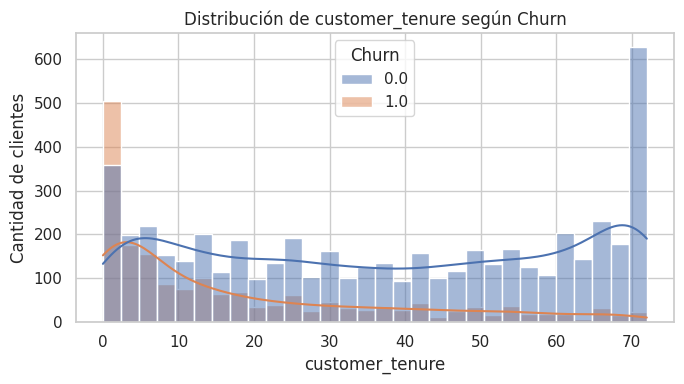

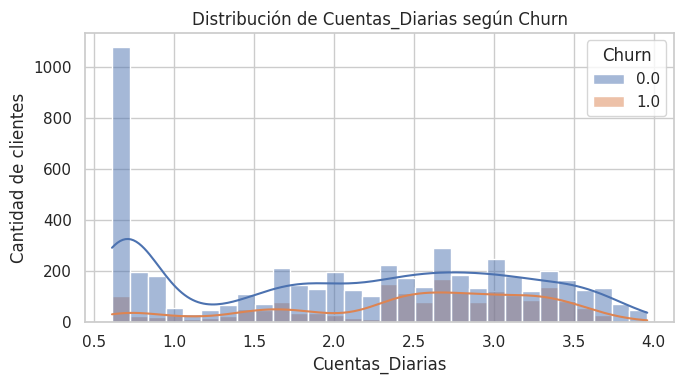

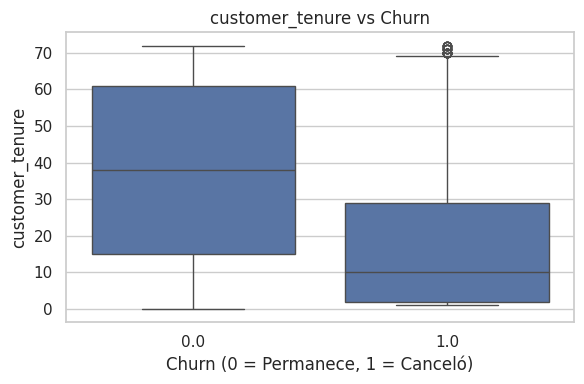

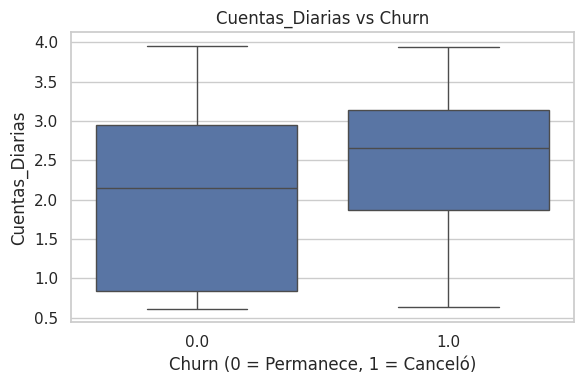

In [10]:
# ============================================
# EVASIÓN SEGÚN VARIABLES NUMÉRICAS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Variables numéricas relevantes
numeric_vars = [
    'customer_tenure',
    'account_Charges_Monthly',
    'account_Charges_Total',
    'Cuentas_Diarias'
]

# ============================================
# 1. HISTOGRAMAS COMPARANDO CHURN
# ============================================

for var in numeric_vars:

    if var in df_final.columns:

        plt.figure(figsize=(7,4))

        sns.histplot(
            data=df_final,
            x=var,
            hue="Churn",
            kde=True,
            bins=30
        )

        plt.title(f"Distribución de {var} según Churn")
        plt.xlabel(var)
        plt.ylabel("Cantidad de clientes")

        plt.tight_layout()
        plt.show()


# ============================================
# 2. BOXPLOTS PARA COMPARAR DISTRIBUCIONES
# ============================================

for var in numeric_vars:

    if var in df_final.columns:

        plt.figure(figsize=(6,4))

        sns.boxplot(
            data=df_final,
            x="Churn",
            y=var
        )

        plt.title(f"{var} vs Churn")
        plt.xlabel("Churn (0 = Permanece, 1 = Canceló)")
        plt.ylabel(var)

        plt.tight_layout()
        plt.show()

**INFORME FINAL**

**Introducción**

La evasión de clientes, también conocida como Churn, es un problema crítico para muchas empresas de telecomunicaciones. Ocurre cuando los clientes deciden cancelar su servicio, lo que impacta directamente en los ingresos y en la estabilidad del negocio.

El objetivo de este análisis es identificar patrones y factores asociados al abandono de clientes utilizando un conjunto de datos de TelecomX. A través de técnicas de limpieza, transformación y análisis exploratorio de datos, se busca comprender mejor el comportamiento de los clientes y detectar posibles causas de evasión.

Los resultados de este análisis pueden ayudar a la empresa a desarrollar estrategias de retención más efectivas y mejorar la experiencia del cliente.


**Limpieza y Tratamiento de Datos**

Para garantizar la calidad del análisis, se realizó un proceso de preparación y limpieza de los datos, que incluyó los siguientes pasos:

**Importación de datos**

Los datos fueron cargados directamente desde un archivo JSON alojado en un repositorio remoto y convertidos en un DataFrame de Pandas para su análisis.


**Análisis Exploratorio de Datos (EDA)**

El análisis exploratorio permitió comprender mejor el comportamiento de los clientes y detectar posibles factores asociados con el churn.

**Distribución de evasión**

Se analizaron las proporciones de clientes que permanecen y los que cancelan el servicio.

**Los resultados muestran que:**

La mayoría de los clientes permanece en la empresa.

Existe un porcentaje significativo de clientes que abandona el servicio, lo que representa una oportunidad para mejorar estrategias de retención.

**Conclusiones**

A partir del análisis realizado, se identificaron algunos factores clave relacionados con la evasión de clientes:

El tiempo de permanencia es un factor importante
Los clientes más nuevos presentan una mayor probabilidad de cancelar el servicio.

El tipo de contrato influye significativamente en el churn
Los contratos mensuales están más asociados con la evasión que los contratos de largo plazo.

Los niveles de gasto pueden influir en el comportamiento del cliente
Diferencias en la facturación mensual pueden afectar la percepción del valor del servicio.

El comportamiento de pago y los servicios contratados también influyen
Algunos métodos de pago y combinaciones de servicios pueden estar asociados con mayores tasas de cancelación.